<a href="https://colab.research.google.com/github/jeevithachandhiran8/patient-readmission-prediction/blob/main/Copy_of_patient_readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data=pd.read_csv("diabetic_data.csv")

In [ ]:
print(data.head());

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [ ]:
print(data.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
print(data.describe())

       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             7.00000

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
print(data["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [ ]:
missing = (data == '?').sum()
print(missing[missing > 0])

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


In [ ]:
# Check current columns in your dataframe
print(data.columns.tolist())
print("Total columns:", data.shape[1])

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
Total columns: 50


In [ ]:
# Safe drop — ignores columns that don't exist
cols_to_drop = [
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty',
    'max_glu_serum',
    'A1Cresult'
]

data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
print("Remaining columns:", data.shape[1])
print(data.columns.tolist())

Remaining columns: 43
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [ ]:
for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    data[col] = data[col].replace('?', 'Unknown')

print("Missing '?' remaining:", (data == '?').sum().sum())

Missing '?' remaining: 0


In [ ]:
data['readmitted'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
print(data['readmitted'].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
# See which columns are still text/object type
cat_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
print("Total:", len(cat_cols))

Categorical columns: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Total: 31


In [ ]:
# Gender, change, diabetesMed have only 2 values
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})
data['change'] = data['change'].map({'No': 0, 'Ch': 1})
data['diabetesMed'] = data['diabetesMed'].map({'No': 0, 'Yes': 1})

print("Binary encoding done!")
print(data[['gender', 'change', 'diabetesMed']].head())

Binary encoding done!
   gender  change  diabetesMed
0     1.0       0            0
1     1.0       1            1
2     1.0       0            1
3     0.0       1            1
4     0.0       1            1


In [ ]:
# Age has order — [10-20) is younger than [20-30)
age_map = {
    '[0-10)'  : 0, '[10-20)': 1, '[20-30)': 2,
    '[30-40)' : 3, '[40-50)': 4, '[50-60)': 5,
    '[60-70)' : 6, '[70-80)': 7, '[80-90)': 8,
    '[90-100)': 9
}
data['age'] = data['age'].map(age_map)
print("Age encoding done!")
print(data['age'].value_counts())

Age encoding done!
age
7    26068
6    22483
5    17256
8    17197
4     9685
3     3775
9     2793
2     1657
1      691
0      161
Name: count, dtype: int64


In [ ]:
# All medicine columns have same values: No, Steady, Up, Down
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}

med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in med_cols:
    data[col] = data[col].map(med_map)

print("Medicine encoding done!")
print(data[med_cols].head())

Medicine encoding done!
   metformin  repaglinide  nateglinide  chlorpropamide  glimepiride  \
0          0            0            0               0            0   
1          0            0            0               0            0   
2          0            0            0               0            0   
3          0            0            0               0            0   
4          0            0            0               0            0   

   acetohexamide  glipizide  glyburide  tolbutamide  pioglitazone  ...  \
0              0          0          0            0             0  ...   
1              0          0          0            0             0  ...   
2              0          1          0            0             0  ...   
3              0          0          0            0             0  ...   
4              0          1          0            0             0  ...   

   troglitazone  tolazamide  examide  citoglipton  insulin  \
0             0           0        0      

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    data[col] = le.fit_transform(data[col].astype(str))

print("Label encoding done!")

Label encoding done!


In [ ]:
# Check no object columns remain
remaining = data.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining)
print("Data shape:", data.shape)
data.head()

Remaining object columns: []
Data shape: (101766, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,1.0,0,6,25,1,1,41,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,1.0,1,1,1,7,3,59,0,18,...,0,2,0,0,0,0,0,1,1,0
2,0,1.0,2,1,1,7,2,11,5,13,...,0,0,0,0,0,0,0,0,1,0
3,2,0.0,3,1,1,7,2,44,1,16,...,0,2,0,0,0,0,0,1,1,0
4,2,0.0,4,1,1,7,1,51,0,8,...,0,1,0,0,0,0,0,1,1,0


In [ ]:
# Final check before modeling
print("Shape:", data.shape)
print("\nAny nulls?", data.isnull().sum().sum())
print("\nTarget distribution:")
print(data['readmitted'].value_counts())
print("\nData types:")
print(data.dtypes.value_counts())

Shape: (101766, 43)

Any nulls? 3

Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64

Data types:
int64      42
float64     1
Name: count, dtype: int64


In [ ]:
# Drop the 3 remaining null rows — too few to matter
data = data.dropna()
print("Nulls remaining:", data.isnull().sum().sum())
print("Shape after dropping nulls:", data.shape)

Nulls remaining: 0
Shape after dropping nulls: (101763, 43)


In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

X = data.drop('readmitted', axis=1)
y = data['readmitted']

print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
readmitted
0    90406
1    11357
Name: count, dtype: int64

After SMOTE:
readmitted
0    90406
1    90406
Name: count, dtype: int64


In [ ]:
plot_data = pd.DataFrame(X_resampled, columns=X.columns)
plot_data['readmitted'] = y_resampled.values
print("Plot data shape:", plot_data.shape)

Plot data shape: (180812, 43)


/tmp/ipykernel_1925/270270698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=plot_data, palette='Set2', ax=axes[0,0])
/tmp/ipykernel_1925/270270698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=plot_data, palette='coolwarm', ax=axes[0,2])
/tmp/ipykernel_1925/270270698.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='num_medications', data=plot_data, palette='Set3', ax=axes[1,0])
/tmp/ipykernel_1925/270270698.py:27: FutureWarning: 

Passing `p

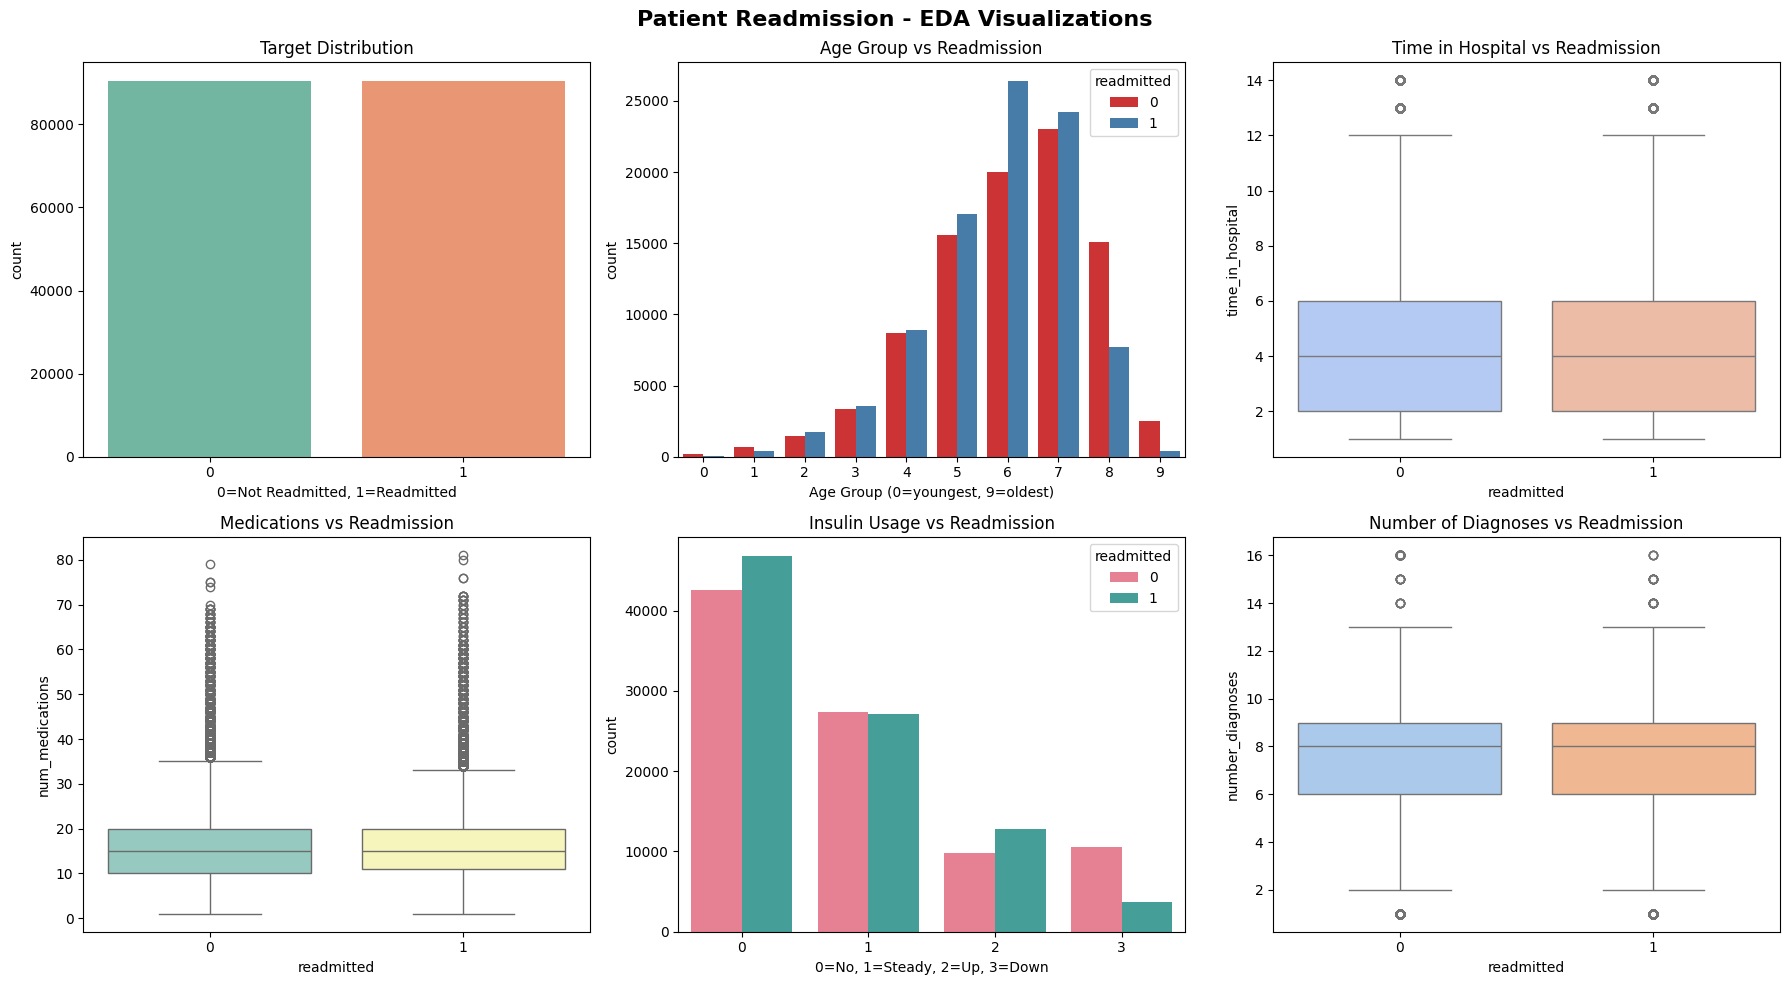

Saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target Distribution
sns.countplot(x='readmitted', data=plot_data, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xlabel('0=Not Readmitted, 1=Readmitted')

# 2. Age vs Readmission
sns.countplot(x='age', hue='readmitted', data=plot_data, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Age Group vs Readmission')
axes[0,1].set_xlabel('Age Group (0=youngest, 9=oldest)')

# 3. Time in Hospital vs Readmission
sns.boxplot(x='readmitted', y='time_in_hospital', data=plot_data, palette='coolwarm', ax=axes[0,2])
axes[0,2].set_title('Time in Hospital vs Readmission')

# 4. Number of Medications vs Readmission
sns.boxplot(x='readmitted', y='num_medications', data=plot_data, palette='Set3', ax=axes[1,0])
axes[1,0].set_title('Medications vs Readmission')

# 5. Insulin vs Readmission
sns.countplot(x='insulin', hue='readmitted', data=plot_data, palette='husl', ax=axes[1,1])
axes[1,1].set_title('Insulin Usage vs Readmission')
axes[1,1].set_xlabel('0=No, 1=Steady, 2=Up, 3=Down')

# 6. Number of Diagnoses vs Readmission
sns.boxplot(x='readmitted', y='number_diagnoses', data=plot_data, palette='pastel', ax=axes[1,2])
axes[1,2].set_title('Number of Diagnoses vs Readmission')

plt.suptitle('Patient Readmission - EDA Visualizations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150)
plt.show()
print("Saved!")

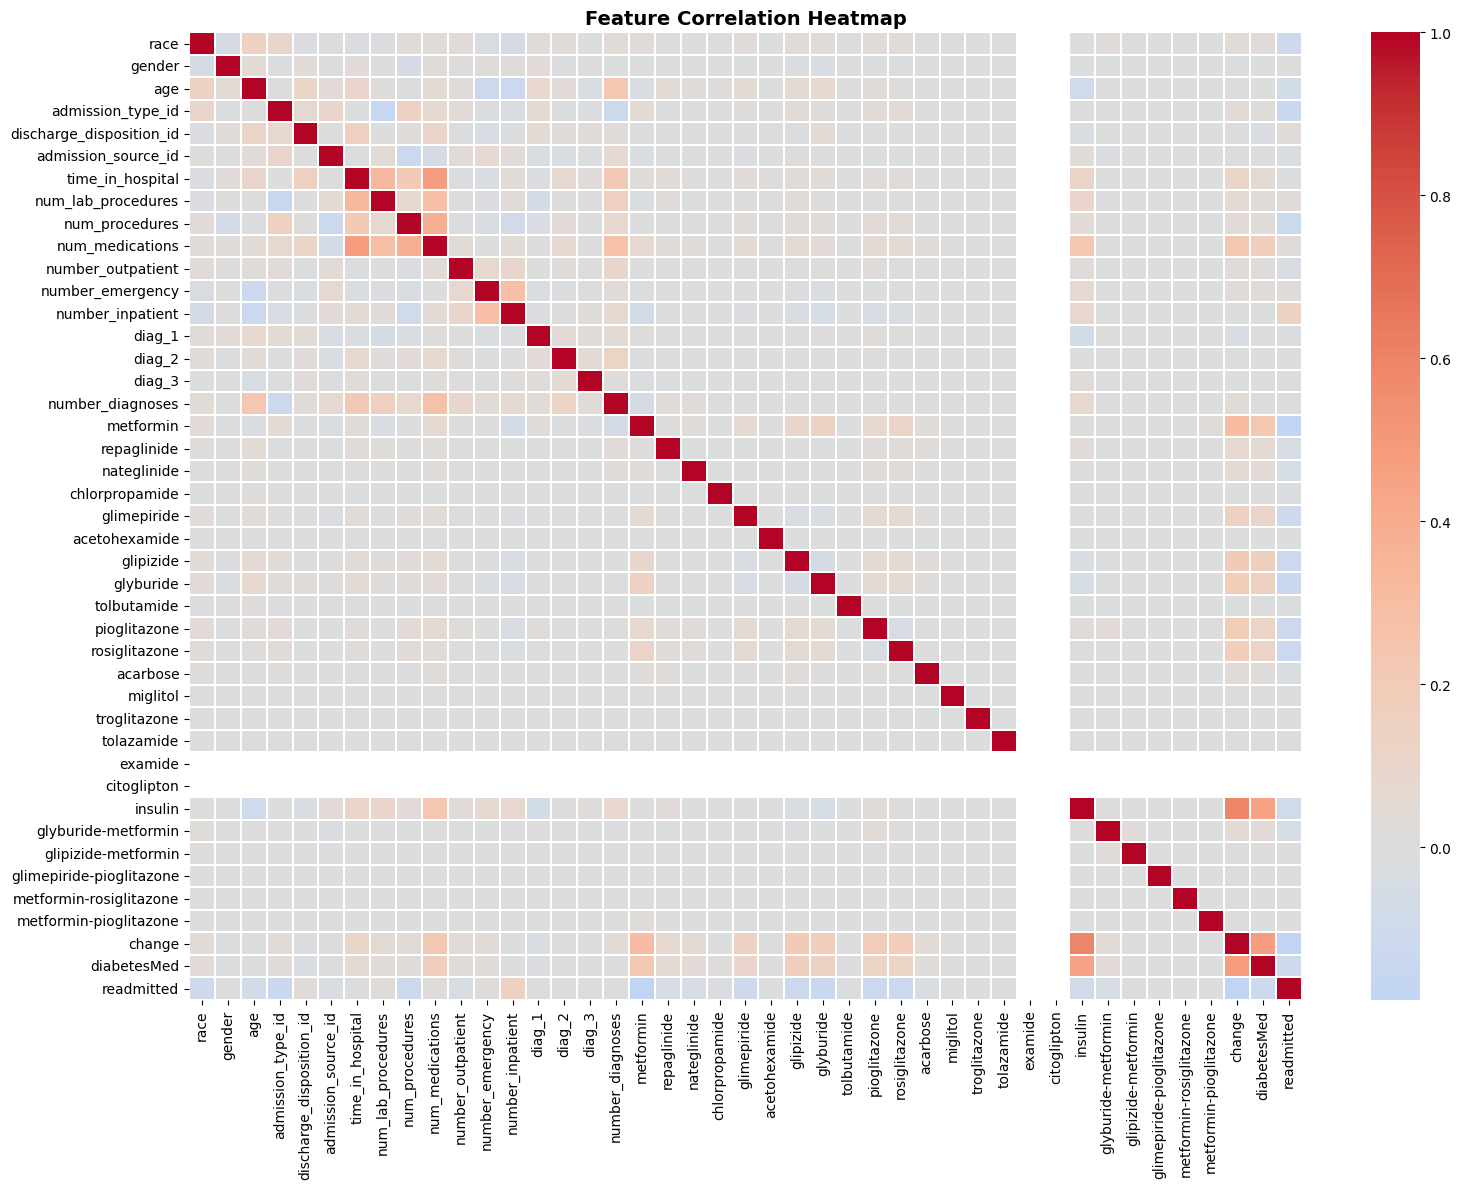

Saved!


In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(plot_data.corr(),
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved!")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

Training size: (144649, 42)
Testing size : (36163, 42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score,classification_report

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Done")



Training Logistic Regression...
Done


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Done")

Training Random Forest...
Done


In [ ]:
print("Training XGBoost...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("All 3 models trained!")

Training XGBoost...
All 3 models trained!


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, xgb_pred)
    ]
})

# Round for clean display
results[['Accuracy','Precision','Recall','ROC-AUC']] = results[['Accuracy','Precision','Recall','ROC-AUC']].round(4)
print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  ROC-AUC
Logistic Regression    0.6774     0.6653  0.7282   0.6768
      Random Forest    0.9088     0.9533  0.8618   0.9093
            XGBoost    0.8824     0.9425  0.8172   0.8831


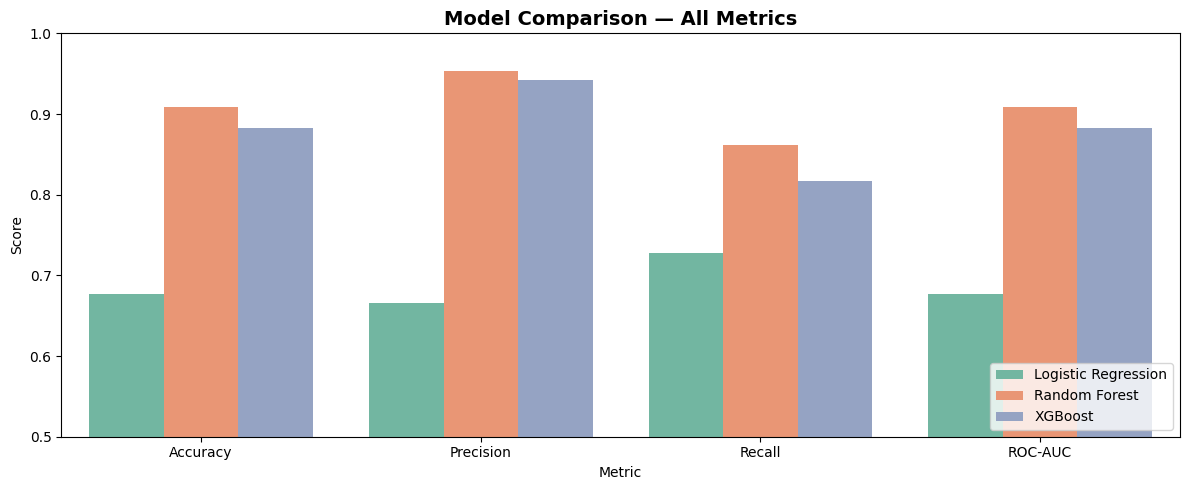

In [ ]:
results_melted = results.melt(id_vars='Model',
                               var_name='Metric',
                               value_name='Score')

plt.figure(figsize=(12,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='Set2')
plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
print("=" * 50)
print("   XGBoost — Detailed Classification Report")
print("=" * 50)
print(classification_report(y_test, xgb_pred,
      target_names=['Not Readmitted', 'Readmitted']))

   XGBoost — Detailed Classification Report
                precision    recall  f1-score   support

Not Readmitted       0.84      0.95      0.89     17884
    Readmitted       0.94      0.82      0.88     18279

      accuracy                           0.88     36163
     macro avg       0.89      0.88      0.88     36163
  weighted avg       0.89      0.88      0.88     36163



/tmp/ipykernel_1925/2135132783.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


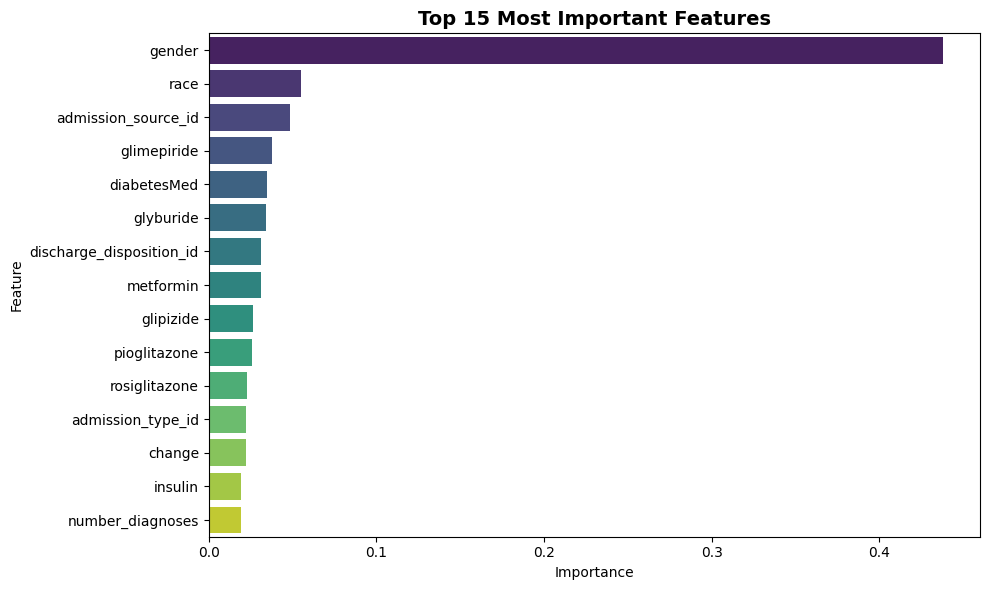


Top 5 Features:
                Feature  Importance
1                gender    0.438054
0                  race    0.055314
5   admission_source_id    0.048640
21          glimepiride    0.037610
41          diabetesMed    0.034895


In [ ]:
# Top 15 most important features
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 Features:")
print(importance.head())

<Figure size 800x600 with 0 Axes>

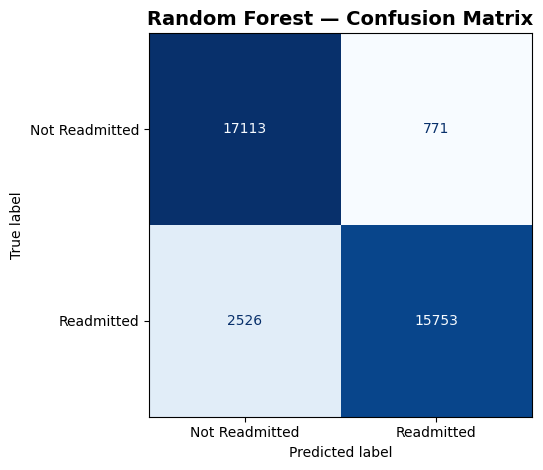

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Readmitted','Readmitted'])

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import numpy as np

# Create a sample patient
# Fill in values for each feature
sample_patient = {
    'race': 2,              # 0-5 (encoded)
    'gender': 1,            # 0=Male, 1=Female
    'age': 7,               # 0-9 (7 = 70-80 years)
    'admission_type_id': 1, # 1=Emergency
    'discharge_disposition_id': 1, # 1=Home
    'admission_source_id': 7,      # 7=Emergency Room
    'time_in_hospital': 8,  # 8 days in hospital
    'num_lab_procedures': 50,
    'num_procedures': 2,
    'num_medications': 20,
    'number_outpatient': 0,
    'number_emergency': 1,
    'number_inpatient': 1,
    'diag_1': 150,          # encoded diagnosis
    'diag_2': 100,
    'diag_3': 80,
    'number_diagnoses': 9,
    'metformin': 1,         # 0=No, 1=Steady, 2=Up, 3=Down
    'repaglinide': 0,
    'nateglinide': 0,
    'chlorpropamide': 0,
    'glimepiride': 0,
    'acetohexamide': 0,
    'glipizide': 1,
    'glyburide': 0,
    'tolbutamide': 0,
    'pioglitazone': 0,
    'rosiglitazone': 0,
    'acarbose': 0,
    'miglitol': 0,
    'troglitazone': 0,
    'tolazamide': 0,
    'examide': 0,
    'citoglipton': 0,
    'insulin': 2,           # 2=Up
    'glyburide-metformin': 0,
    'glipizide-metformin': 0,
    'glimepiride-pioglitazone': 0,
    'metformin-rosiglitazone': 0,
    'metformin-pioglitazone': 0,
    'change': 1,            # 0=No, 1=Changed
    'diabetesMed': 1        # 0=No, 1=Yes
}

# Convert to dataframe
sample_df = pd.DataFrame([sample_patient])

# Predict
prediction = rf.predict(sample_df)
probability = rf.predict_proba(sample_df)

print("=" * 40)
print("       PATIENT PREDICTION RESULT")
print("=" * 40)
print(f"Readmission Risk : {'🔴 HIGH RISK' if prediction[0] == 1 else '🟢 LOW RISK'}")
print(f"Not Readmitted   : {probability[0][0]*100:.1f}%")
print(f"Readmitted       : {probability[0][1]*100:.1f}%")
print("=" * 40)

       PATIENT PREDICTION RESULT
Readmission Risk : 🟢 LOW RISK
Not Readmitted   : 71.0%
Readmitted       : 29.0%
